# Cahn-Hilliard loss visual check

This notebook loads the example predicted and true metadata, builds Cahn-Hilliard landscapes for two cell types first, visualizes the fields and energy densities, then computes the normalized exponential AUC loss for every cell type.

Note that the HYPERPARAMETERS HERE TESTED are GOOD FOR TRAINING

RADII =np.linspace(0.001, 0.01, 10)

GRID_RESOLUTION = 256

KAPPA = 0.5

SOFT_MAX_BETA = 32.0

SUPPORT_FACTOR = 64.0

MARGIN = 0.01

SQUARE_BBOX = True

EPS = 1e-6

MIN_CELLS_PER_TYPE = 10

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Make the notebook robust whether it is launched from the repo root or metrics/.
cwd = Path.cwd()
if (cwd / "example" / "example_result").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "example" / "example_result").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not find repo root from {cwd}")

METRICS_DIR = REPO_ROOT / "metrics"
for path in (REPO_ROOT, METRICS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from loss_function_plus import (  # noqa: E402
    build_continuous_landscape_from_points,
    cahn_hilliard_energy,
    cahn_hilliard_energy_density,
    shared_square_grid,
    sigmoid_bump,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
print(f"Repo root: {REPO_ROOT}")
print(f"Using device: {DEVICE}")

Repo root: /home/asalmona/Documents/Ricci/code/Tissue-Reassembly-using-GenAI-and-new-metrics
Using device: cpu


## Load and align metadata

The two CSVs share the unnamed first column as the cell ID. We align prediction and ground truth by that ID before comparing positions.

In [ ]:
pred_path = REPO_ROOT / "example" / "example_result" / "metadata_pred.csv"
true_path = REPO_ROOT / "example" / "example_result" / "metadata_true.csv"

pred_df = pd.read_csv(pred_path, index_col=0)
true_df = pd.read_csv(true_path, index_col=0)

required_columns = {"cell_class", "coord_X", "coord_Y"}
for name, df in {"pred": pred_df, "true": true_df}.items():
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{name} metadata is missing columns: {sorted(missing)}")

common_ids = true_df.index.intersection(pred_df.index)
if len(common_ids) == 0:
    raise ValueError("No shared cell IDs between true and predicted metadata.")

true_df = true_df.loc[common_ids].copy()
pred_df = pred_df.loc[common_ids].copy()

class_mismatch = (true_df["cell_class"].astype(str) != pred_df["cell_class"].astype(str)).sum()
print(f"Aligned cells: {len(common_ids)}")
print(f"Cell-class mismatches between files: {class_mismatch}")

display(true_df.head())
display(true_df["cell_class"].value_counts().rename("n_cells").to_frame())

Aligned cells: 3780
Cell-class mismatches between files: 0


,cell_class,coord_X,coord_Y
133277,Oligo,0.026848,0.116121
91841,Astro,0.052199,0.381970
55540,L6 CT,0.160931,0.067541
55257,L5 IT,0.063948,0.133388
103231,L5 ET,0.023917,0.035204


,n_cells
cell_class,
L4/5 IT,558
L2/3 IT,476
L6 CT,447
L5 IT,310
Oligo,298
Astro,296
Endo,253
L6 IT,193
L5 ET,163


## Parameters and helper functions

These values mirror the implementation in `loss_function_plus.py`. The loss compares the AUC of the Cahn-Hilliard energy curve across `RADII`.

In [3]:
# You can change these to match a training run.
RADII =np.linspace(0.001, 0.01, 10)
GRID_RESOLUTION = 256
KAPPA = 0.5
SOFT_MAX_BETA =  64.0
SUPPORT_FACTOR = 64.0
MARGIN = 0.01
SQUARE_BBOX = True
EPS = 1e-6
MIN_CELLS_PER_TYPE = 10

true_pos = torch.tensor(true_df[["coord_X", "coord_Y"]].to_numpy(), dtype=DTYPE, device=DEVICE)
pred_pos = torch.tensor(pred_df[["coord_X", "coord_Y"]].to_numpy(), dtype=DTYPE, device=DEVICE)
cell_labels = true_df["cell_class"].astype(str)


def bump_kwargs_for_radius(radius):
    # This matches CahnHilliardEnergyAUCLoss._landscape in loss_function_plus.py.
    return {"decay_rate": 2 / radius, "shift": 128 * radius}


def type_mask_for(cell_type):
    return torch.tensor((cell_labels.values == cell_type), dtype=torch.bool, device=DEVICE)


def landscape_for_points(points, grid_x, grid_y, radius):
    valid_mask = torch.ones(points.shape[0], dtype=torch.bool, device=points.device)
    return build_continuous_landscape_from_points(
        points,
        valid_mask,
        grid_x,
        grid_y,
        radius=radius,
        bump_fn=sigmoid_bump,
        bump_kwargs=bump_kwargs_for_radius(radius),
        combine="soft_max",
        soft_max_beta=SOFT_MAX_BETA,
        support_factor=SUPPORT_FACTOR,
    )


def compute_type_curves(cell_type):
    mask = type_mask_for(cell_type)
    n_cells = int(mask.sum().item())
    if n_cells < MIN_CELLS_PER_TYPE:
        return None

    true_type = true_pos[mask]
    pred_type = pred_pos[mask]
    grid_x, grid_y, dx, dy = shared_square_grid(
        true_type,
        pred_type,
        grid_resolution=GRID_RESOLUTION,
        margin=MARGIN,
        square=SQUARE_BBOX,
    )

    e_true_curve = []
    e_pred_curve = []
    phi_by_radius = {}
    energy_density_by_radius = {}

    for radius in RADII:
        phi_true = landscape_for_points(true_type, grid_x, grid_y, radius)
        phi_pred = landscape_for_points(pred_type, grid_x, grid_y, radius)

        energy_density_true = cahn_hilliard_energy_density(phi_true, dx, dy, kappa=KAPPA)
        energy_density_pred = cahn_hilliard_energy_density(phi_pred, dx, dy, kappa=KAPPA)

        e_true_curve.append(energy_density_true.sum() * dx * dy)
        e_pred_curve.append(energy_density_pred.sum() * dx * dy)
        phi_by_radius[radius] = (phi_true, phi_pred)
        energy_density_by_radius[radius] = (energy_density_true, energy_density_pred)

    radii_t = torch.tensor(RADII, dtype=DTYPE, device=DEVICE)
    e_true_t = torch.stack(e_true_curve)
    e_pred_t = torch.stack(e_pred_curve)
    auc_true = torch.trapezoid(e_true_t, radii_t)
    auc_pred = torch.trapezoid(e_pred_t, radii_t)

    relative_auc_diff = (auc_pred - auc_true).abs() / (auc_true.detach().abs() + EPS)
    exp_normalized_loss = 1.0 - torch.exp(-relative_auc_diff)

    return {
        "cell_type": cell_type,
        "n_cells": n_cells,
        "grid_x": grid_x,
        "grid_y": grid_y,
        "dx": dx,
        "dy": dy,
        "e_true_curve": e_true_t,
        "e_pred_curve": e_pred_t,
        "auc_true": auc_true,
        "auc_pred": auc_pred,
        "relative_auc_diff": relative_auc_diff,
        "loss_exp_normalized": exp_normalized_loss,
        "phi_by_radius": phi_by_radius,
        "energy_density_by_radius": energy_density_by_radius,
    }


def to_numpy(tensor):
    return tensor.detach().cpu().numpy()

## Pick two cell types and build landscapes

By default, this chooses the two most abundant cell types so the landscapes are easy to inspect. Change `selected_cell_types` manually if you want to inspect specific classes.

In [4]:
selected_cell_types = ['Endo', 'VLMC']
visual_radius = 0.01

with torch.no_grad():
    visual_results = {cell_type: compute_type_curves(cell_type) for cell_type in selected_cell_types}

print(f"Selected cell types: {selected_cell_types}")
print(f"Visual radius: {visual_radius}")

Selected cell types: ['Endo', 'VLMC']
Visual radius: 0.01


## Plot continuous landscapes

Each row is one cell type. Columns show the true landscape, predicted landscape, and their difference at `visual_radius`.

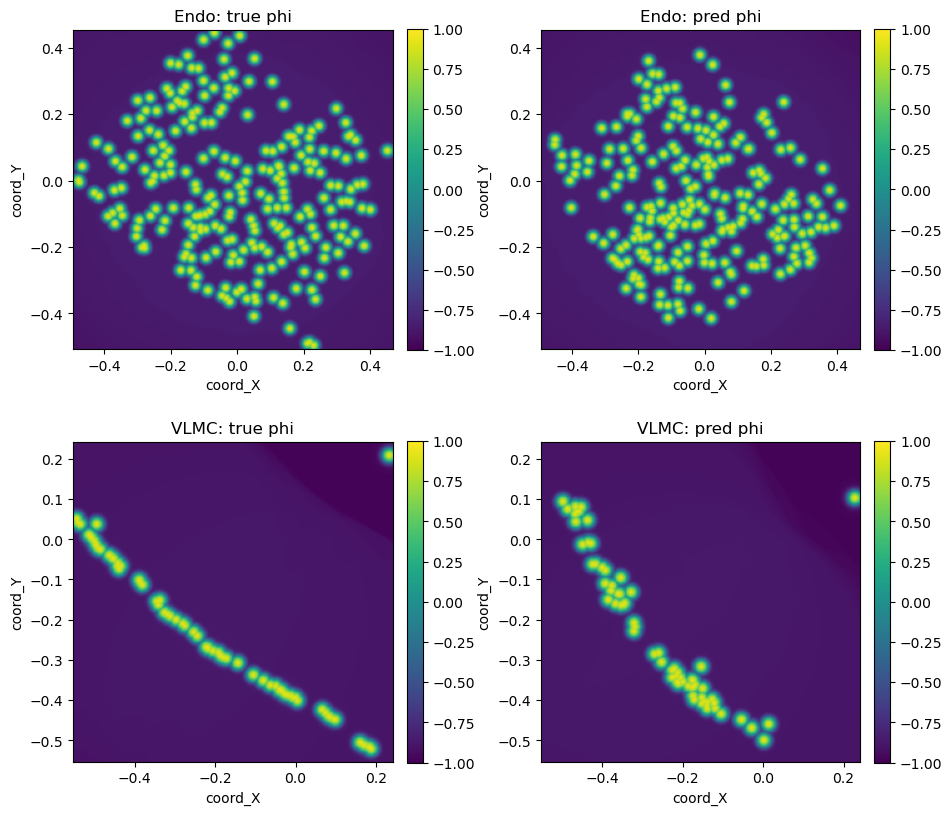

In [5]:
fig, axes = plt.subplots(len(selected_cell_types), 2, figsize=(9.5, 4.2 * len(selected_cell_types)), squeeze=False)

for row, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    phi_true, phi_pred = result["phi_by_radius"][visual_radius]
    grid_x = result["grid_x"]
    grid_y = result["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(), grid_y.min().item(), grid_y.max().item()]

    panels = [
        (phi_true, "true phi", "viridis", -1.0, 1.0),
        (phi_pred, "pred phi", "viridis", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(to_numpy(image), origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{cell_type}: {title}")
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
   

plt.tight_layout()

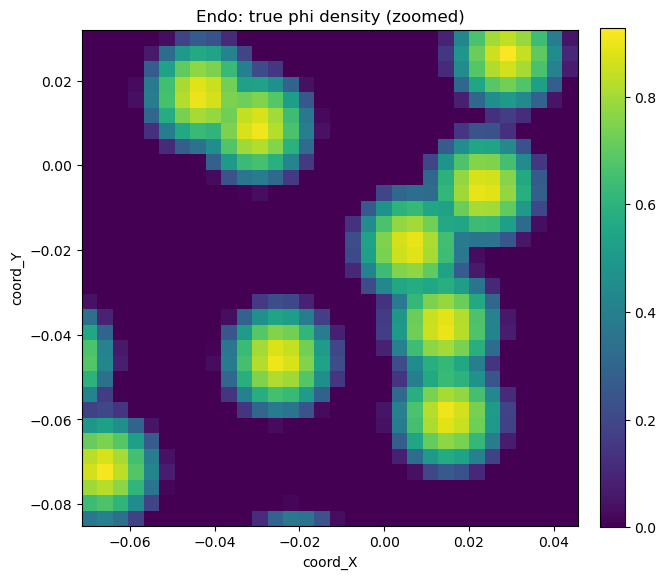

In [6]:
# Plot a zoomed-in view of the first "true energy density" panel for the first cell type

cell_type = selected_cell_types[0]
result = visual_results[cell_type]
e_true = result["phi_by_radius"][visual_radius][0]
grid_x = result["grid_x"]
grid_y = result["grid_y"]

# Choose zoom center and width/height: center and show a region that's 1/8 of the original area
h, w = e_true.shape
zoom_factor = 8
zh = h // (2 * zoom_factor)
zw = w // (2 * zoom_factor)
center_y = h // 2
center_x = w // 2
zoomed = e_true[center_y-zh:center_y+zh, center_x-zw:center_x+zw]

zoomed_extent = [
    float(grid_x[center_x-zw]),
    float(grid_x[center_x+zw-1]),
    float(grid_y[center_y-zh]),
    float(grid_y[center_y+zh-1]),
]

plt.figure(figsize=(7, 7))
plt.imshow(to_numpy(zoomed), origin="lower", extent=zoomed_extent, vmin=0.0, vmax=float(e_true.max().item()))
plt.title(f"{cell_type}: true phi density (zoomed)")
plt.xlabel("coord_X")
plt.ylabel("coord_Y")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

## Plot Cahn-Hilliard energy densities

These are the per-grid-cell energy densities `(phi^2 - 1)^2 + kappa * |grad phi|^2` for the same two cell types and radius.

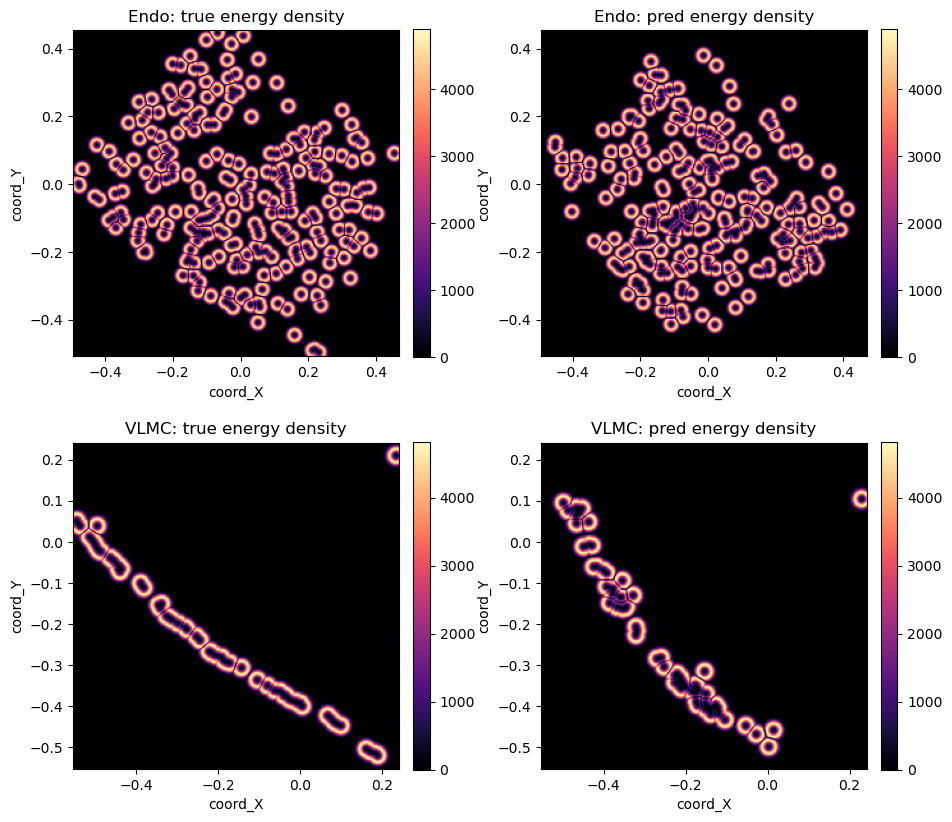

In [7]:
fig, axes = plt.subplots(len(selected_cell_types), 2, figsize=(9.5, 4.2 * len(selected_cell_types)), squeeze=False)

for row, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    e_true, e_pred = result["energy_density_by_radius"][visual_radius]
    diff = e_pred - e_true
    grid_x = result["grid_x"]
    grid_y = result["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(), grid_y.min().item(), grid_y.max().item()]
    shared_vmax = max(float(e_true.max().item()), float(e_pred.max().item()))

    panels = [
        (e_true, "true energy density", "magma", 0.0, shared_vmax),
        (e_pred, "pred energy density", "magma", 0.0, shared_vmax),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(to_numpy(image), origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{cell_type}: {title}")
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

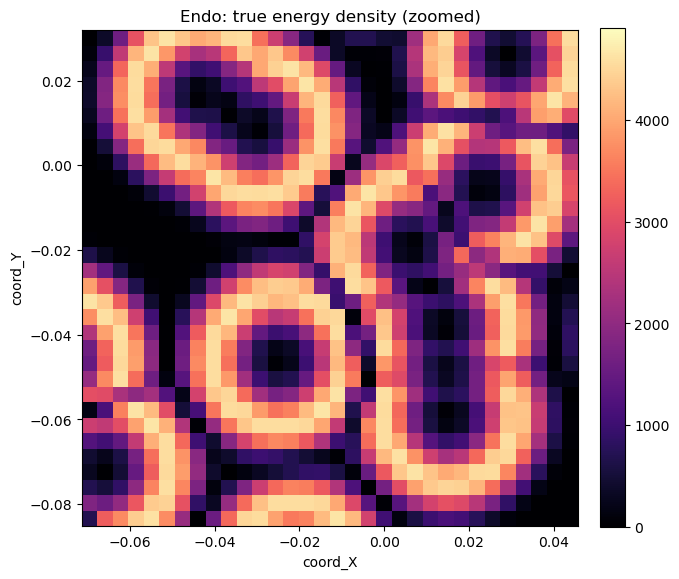

In [8]:
# Plot a zoomed-in view of the first "true energy density" panel for the first cell type

cell_type = selected_cell_types[0]
result = visual_results[cell_type]
e_true = result["energy_density_by_radius"][visual_radius][0]
grid_x = result["grid_x"]
grid_y = result["grid_y"]

# Choose zoom center and width/height: center and show a region that's 1/8 of the original area
h, w = e_true.shape
zoom_factor = 8
zh = h // (2 * zoom_factor)
zw = w // (2 * zoom_factor)
center_y = h // 2
center_x = w // 2
zoomed = e_true[center_y-zh:center_y+zh, center_x-zw:center_x+zw]

zoomed_extent = [
    float(grid_x[center_x-zw]),
    float(grid_x[center_x+zw-1]),
    float(grid_y[center_y-zh]),
    float(grid_y[center_y+zh-1]),
]

plt.figure(figsize=(7, 7))
plt.imshow(to_numpy(zoomed), origin="lower", extent=zoomed_extent, cmap="magma", vmin=0.0, vmax=float(e_true.max().item()))
plt.title(f"{cell_type}: true energy density (zoomed)")
plt.xlabel("coord_X")
plt.ylabel("coord_Y")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

## Plot energy curves for the two visualized cell types

The final loss compares the trapezoidal AUCs of these curves.

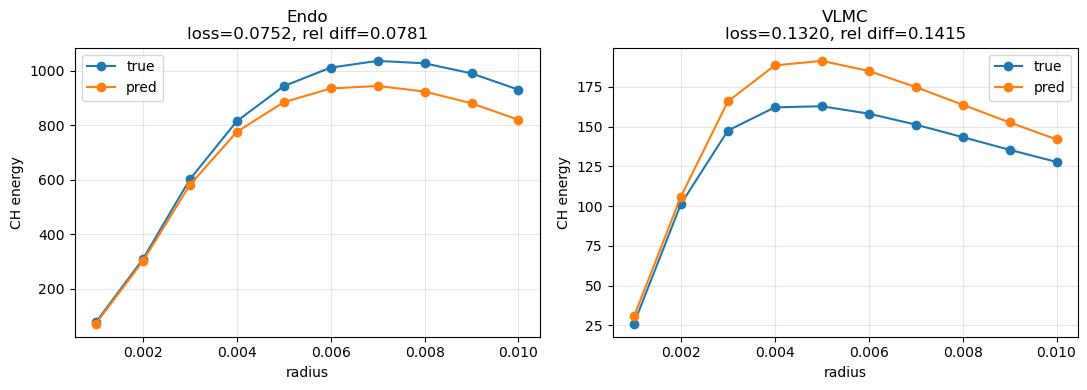

In [9]:
fig, axes = plt.subplots(1, len(selected_cell_types), figsize=(5.5 * len(selected_cell_types), 4), squeeze=False)

for col, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    ax = axes[0, col]
    ax.plot(RADII, to_numpy(result["e_true_curve"]), marker="o", label="true")
    ax.plot(RADII, to_numpy(result["e_pred_curve"]), marker="o", label="pred")
    ax.set_title(
        f"{cell_type}\n"
        f"loss={result['loss_exp_normalized'].item():.4f}, "
        f"rel diff={result['relative_auc_diff'].item():.4f}"
    )
    ax.set_xlabel("radius")
    ax.set_ylabel("CH energy")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

## Compute the loss for every cell type

For each cell type, this computes:

`relative_auc_diff = abs(AUC_pred - AUC_true) / (abs(AUC_true) + EPS)`

`loss_exp_normalized = 1 - exp(-relative_auc_diff)`

In [10]:
all_results = []

with torch.no_grad():
    for cell_type in cell_labels.value_counts().index:
        result = compute_type_curves(cell_type)
        if result is None:
            continue
        all_results.append(
            {
                "cell_type": cell_type,
                "n_cells": result["n_cells"],
                "auc_true": result["auc_true"].item(),
                "auc_pred": result["auc_pred"].item(),
                "relative_auc_diff": result["relative_auc_diff"].item(),
                "loss_exp_normalized": result["loss_exp_normalized"].item(),
            }
        )

loss_df = pd.DataFrame(all_results).sort_values("loss_exp_normalized", ascending=False)
display(loss_df)

,cell_type,n_cells,auc_true,auc_pred,relative_auc_diff,loss_exp_normalized
17,SMC,48,1.139663,1.647665,0.445747,0.359654
16,L6b,54,1.149034,1.447406,0.259671,0.228695
13,PVM,79,2.021876,2.535728,0.254146,0.224421
14,VLMC,71,1.238510,1.413797,0.141531,0.131972
3,L5 IT,310,6.224102,5.608897,0.098842,0.094115
5,Astro,296,8.201635,7.485402,0.087328,0.083624
6,Endo,253,7.233098,6.667895,0.078141,0.075166
12,OPC,81,2.507168,2.697123,0.075765,0.072966
11,Micro,93,3.146225,2.917339,0.072749,0.070166
4,Oligo,298,6.224690,5.812399,0.066235,0.064089


## Plot normalized exponential loss for all cell types

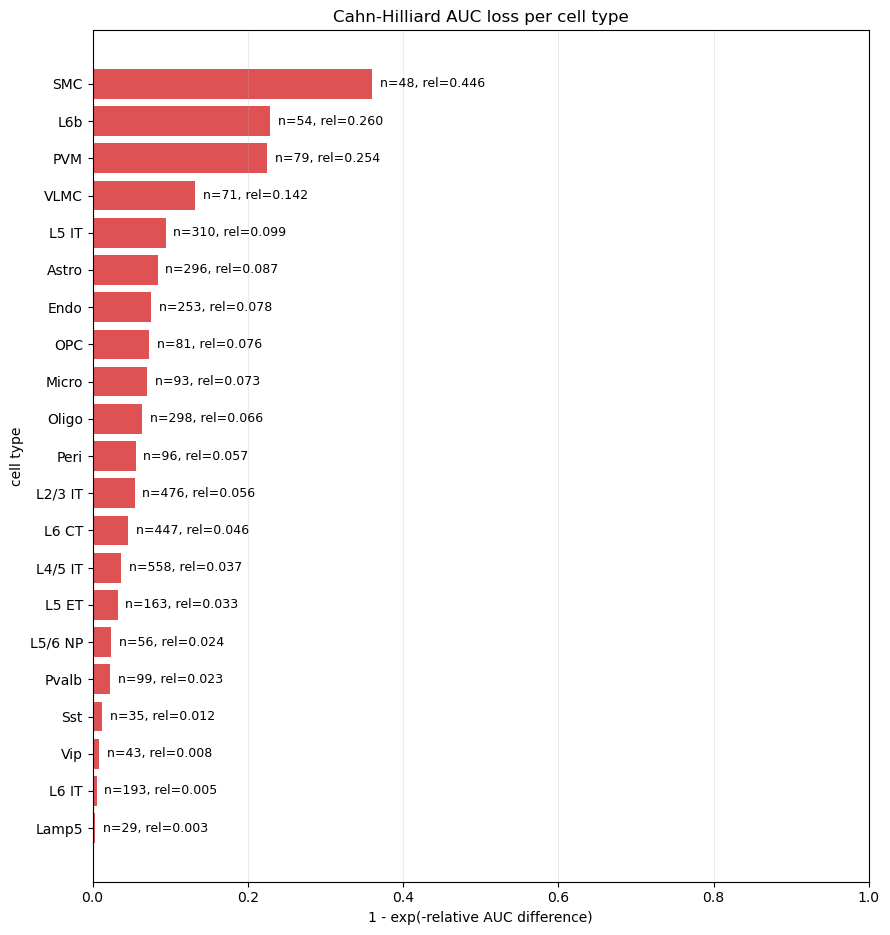

In [11]:
plot_df = loss_df.sort_values("loss_exp_normalized", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df["cell_type"], plot_df["loss_exp_normalized"], color="tab:red", alpha=0.8)
ax.set_xlabel("1 - exp(-relative AUC difference)")
ax.set_ylabel("cell type")
ax.set_title("Cahn-Hilliard AUC loss per cell type")
ax.set_xlim(0, max(1.0, float(plot_df["loss_exp_normalized"].max()) * 1.05))
ax.grid(axis="x", alpha=0.25)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["loss_exp_normalized"] + 0.01,
        i,
        f"n={int(row['n_cells'])}, rel={row['relative_auc_diff']:.3f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()

## Compute the combined loss

This calls `CombinedLossFunction` from `loss_function_plus.py` on the whole slice with original pairwise-distance MSE weight `1.0` and Cahn-Hilliard weight `1e-3`.

## Compute pairwise-distance MSE on the whole slice

This uses `LossFunction` from `loss_function.py`, which compares the full pairwise distance matrices between the true and predicted positions.

In [12]:
import sys
sys.path.insert(0, str(REPO_ROOT))
from loss_function import LossFunction as PairwiseDistanceMSELossFunction  # noqa: E402
from utils.data.dataholder import DataHolder

def make_position_dataholder(df: pd.DataFrame) -> DataHolder:
    positions = torch.as_tensor(
        df[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32),
        device=DEVICE,
        dtype=DTYPE,
    ).unsqueeze(0)
    node_features = torch.zeros((1, positions.shape[1], 1), device=DEVICE, dtype=DTYPE)
    node_mask = torch.ones((1, positions.shape[1]), device=DEVICE, dtype=torch.bool)
    return DataHolder(
        positions=positions,
        node_features=node_features,
        diffusion_time=None,
        node_mask=node_mask,
    )


true_holder = make_position_dataholder(true_df)
pred_holder = make_position_dataholder(pred_df)
pairwise_mse_loss_fn = PairwiseDistanceMSELossFunction().to(DEVICE)

with torch.no_grad():
    pairwise_mse_loss, _ = pairwise_mse_loss_fn(
        masked_pred=pred_holder,
        masked_true=true_holder,
        train_stage=False,
        log=False,
    )

n_cells = int(true_holder.node_mask.sum().item())
n_pairwise_entries = n_cells * n_cells
print(f"Cells in whole slice: {n_cells:,}")
print(f"Pairwise distance entries compared: {n_pairwise_entries:,}")
print(f"Pairwise-distance MSE loss from loss_function.py: {pairwise_mse_loss.item():.6g}")

if "loss_df" in globals() and len(loss_df) > 0:
    weighted_ch_loss = np.average(loss_df["loss_exp_normalized"], weights=np.log(loss_df["n_cells"]))
    print(
        "Cahn-Hilliard normalized loss across cell types: "
        f"mean={loss_df['loss_exp_normalized'].mean():.6g}, "
        f"weighted_mean={weighted_ch_loss:.6g}, "
        f"max={loss_df['loss_exp_normalized'].max():.6g},"
        f"total_loss={loss_df['loss_exp_normalized'].sum()}"
    )

Cells in whole slice: 3,780
Pairwise distance entries compared: 14,288,400
Pairwise-distance MSE loss from loss_function.py: 0.0362132
Cahn-Hilliard normalized loss across cell types: mean=0.0811291, weighted_mean=0.0778354, max=0.359654,total_loss=1.7037120461463928


In [13]:
from loss_function_plus import CombinedLossFunction  # noqa: E402


def make_combined_loss_dataholders(
    pred_df: pd.DataFrame,
    true_df: pd.DataFrame,
) -> tuple[DataHolder, DataHolder, dict[int, str]]:
    pred_positions = torch.as_tensor(
        pred_df[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32),
        device=DEVICE,
        dtype=DTYPE,
    ).unsqueeze(0)
    true_positions = torch.as_tensor(
        true_df[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32),
        device=DEVICE,
        dtype=DTYPE,
    ).unsqueeze(0)

    class_categories = pd.Categorical(true_df["cell_class"].astype(str))
    cell_class = torch.as_tensor(
        class_categories.codes,
        device=DEVICE,
        dtype=torch.long,
    ).unsqueeze(0)
    class_id_to_name = dict(enumerate(class_categories.categories.astype(str)))

    n_cells = true_positions.shape[1]
    node_features = torch.zeros((1, n_cells, 1), device=DEVICE, dtype=DTYPE)
    node_mask = torch.ones((1, n_cells), device=DEVICE, dtype=torch.bool)

    pred_holder = DataHolder(
        positions=pred_positions,
        node_features=node_features.clone(),
        diffusion_time=None,
        node_mask=node_mask,
    )
    true_holder = DataHolder(
        positions=true_positions,
        node_features=node_features,
        diffusion_time=None,
        cell_class=cell_class,
        node_mask=node_mask,
    )
    return pred_holder, true_holder, class_id_to_name


combined_pred_holder, combined_true_holder, class_id_to_name = make_combined_loss_dataholders(
    pred_df,
    true_df,
)

combined_loss_fn = CombinedLossFunction(
    mse_weight=1.0,
    ch_weight=1e-3,
    radii=RADII,
    grid_resolution=GRID_RESOLUTION,
    kappa=KAPPA,
    soft_max_beta=SOFT_MAX_BETA,
    support_factor=SUPPORT_FACTOR,
    square_bbox=SQUARE_BBOX,
    margin=MARGIN,
    eps=EPS,
    min_cells_per_type=MIN_CELLS_PER_TYPE,
).to(DEVICE)

with torch.no_grad():
    mse_component, _ = combined_loss_fn.mse_loss(
        combined_pred_holder,
        combined_true_holder,
        train_stage=False,
        log=False,
    )
    ch_component, _ = combined_loss_fn.ch_loss(
        combined_pred_holder,
        combined_true_holder,
        train_stage=False,
        log=False,
    )
    combined_loss, _ = combined_loss_fn(
        combined_pred_holder,
        combined_true_holder,
        train_stage=False,
        log=False,
    )

print(f"Cells in whole slice: {int(combined_true_holder.node_mask.sum().item()):,}")
print(f"Cell types included: {len(class_id_to_name)}")
print(f"Original pairwise-distance MSE component: {mse_component.item():.6g}")
print(f"Cahn-Hilliard component before weighting: {ch_component.item():.6g}")
print(f"Weighted Cahn-Hilliard contribution (1e-3 * CH): {(1e-3 * ch_component).item():.6g}")
print(f"Total combined loss: {combined_loss.item():.6g}")

/tmp/ipykernel_348992/2488884214.py:20: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  cell_class = torch.as_tensor(


Cells in whole slice: 3,780
Cell types included: 22
Original pairwise-distance MSE component: 0.0362132
Cahn-Hilliard component before weighting: 0.00351179
Weighted Cahn-Hilliard contribution (1e-3 * CH): 3.51179e-06
Total combined loss: 0.0362167


# Voronoi phase-pair Cahn-Hilliard loss

This section mirrors the visual check above but for the new
`VoronoiPhasePairEnergyLoss`.

For each unordered pair of cell types `(A, B)` we build a smooth two-phase landscape on a shared grid:

\[
\phi_{AB}(x) = \tanh\!\left(\frac{d_A(x) - d_B(x)}{w}\right)
\]

where $d_t(x)$ is the distance from grid point $x$ to the nearest cell of type $t$.
This gives $\phi \approx -1$ near A-cells, $+1$ near B-cells, with a smooth Voronoi-frontier transition (width `transition_width`).

The Cahn-Hilliard energy is then evaluated on $\phi_{AB}$ for both ground-truth and predicted positions, and the per-pair loss is

\[
L_{AB} = 1 - \exp\!\left(-\frac{|E_{\text{pred}} - E_{\text{gt}}|}{|E_{\text{gt}}| + \varepsilon}\right).
\]

In [ ]:
# Pull the new helpers and the loss module from loss_function_plus.py.
from loss_function_plus import (  # noqa: E402
    compute_distance_field_per_type,
    voronoi_phase_field,
    VoronoiPhasePairEnergyLoss,
)

# Hyperparameters for the Voronoi phase-pair loss. Coordinates in this dataset
# live in [0, 1], so a transition width of ~0.01 gives a sharp Voronoi frontier
# (comparable in scale to the RADII used in the CH-AUC test above).
VORONOI_TRANSITION_WIDTH = 0.005
VORONOI_GRID_RESOLUTION = 256
VORONOI_KAPPA = 0.5
# soft_beta=None -> exact min (sub-differentiable, gradient through the closest
# cell only). This is fine for this visual check since we never call backward().
# Set a positive float (e.g. 200.0) to use the smooth softmin during training.
VORONOI_SOFT_BETA = 1024
VORONOI_SQUARE_BBOX = True
VORONOI_MARGIN = 0.01
VORONOI_EPS = 1e-6
VORONOI_MIN_CELLS_PER_PAIR = 10  # need this many cells of *each* type to use a pair


def compute_pair_results(cell_type_a: str, cell_type_b: str) -> dict | None:
    """Build the Voronoi phase landscape, CH energy density and loss for one pair.

    Mirrors `compute_type_curves` from the single-cell-type test above, but
    returns everything needed to visualize and quantify the pair (A, B).
    Returns None if either cell type has fewer than VORONOI_MIN_CELLS_PER_PAIR
    cells in the slice.
    """
    mask_a = type_mask_for(cell_type_a)
    mask_b = type_mask_for(cell_type_b)
    n_a = int(mask_a.sum().item())
    n_b = int(mask_b.sum().item())
    if n_a < VORONOI_MIN_CELLS_PER_PAIR or n_b < VORONOI_MIN_CELLS_PER_PAIR:
        return None

    # Shared grid covering the union bbox of all participating cells (gt + pred).
    used_mask = mask_a | mask_b
    grid_x, grid_y, dx, dy = shared_square_grid(
        true_pos[used_mask],
        pred_pos[used_mask],
        grid_resolution=VORONOI_GRID_RESOLUTION,
        margin=VORONOI_MARGIN,
        square=VORONOI_SQUARE_BBOX,
    )

    # Per-type distance-to-nearest-cell fields, computed once per side. In the
    # full loss these are reused across every pair that involves the type;
    # here we only have one pair per call so it's just two cdists per side.
    type_masks = {"a": mask_a, "b": mask_b}
    gt_dists = compute_distance_field_per_type(
        true_pos, type_masks, grid_x, grid_y,
        soft_beta=VORONOI_SOFT_BETA,
    )
    pred_dists = compute_distance_field_per_type(
        pred_pos, type_masks, grid_x, grid_y,
        soft_beta=VORONOI_SOFT_BETA,
    )

    # phi_AB = tanh((dist_A - dist_B) / w). Bounded in [-1, 1] by tanh.
    phi_true = voronoi_phase_field(gt_dists["a"], gt_dists["b"], VORONOI_TRANSITION_WIDTH)
    phi_pred = voronoi_phase_field(pred_dists["a"], pred_dists["b"], VORONOI_TRANSITION_WIDTH)

    # Cahn-Hilliard energy density and integrated energy on each landscape.
    e_density_true = cahn_hilliard_energy_density(phi_true, dx, dy, kappa=VORONOI_KAPPA)
    e_density_pred = cahn_hilliard_energy_density(phi_pred, dx, dy, kappa=VORONOI_KAPPA)
    e_true = e_density_true.sum() * dx * dy
    e_pred = e_density_pred.sum() * dx * dy

    # Same bounded normalised exp form used in VoronoiPhasePairEnergyLoss.
    rel = (e_pred - e_true).abs() / (e_true.detach().abs() + VORONOI_EPS)
    loss = 1.0 - torch.exp(-rel)

    return {
        "pair": (cell_type_a, cell_type_b),
        "n_a": n_a,
        "n_b": n_b,
        "grid_x": grid_x,
        "grid_y": grid_y,
        "dx": dx,
        "dy": dy,
        "phi_true": phi_true,
        "phi_pred": phi_pred,
        "energy_density_true": e_density_true,
        "energy_density_pred": e_density_pred,
        "e_true": e_true,
        "e_pred": e_pred,
        "rel_diff": rel,
        "loss": loss,
    }

## Pick a few cell-type pairs and build landscapes

By default this picks all unordered pairs from the three most abundant cell types (so 3 pairs). Set `selected_pairs` manually to inspect specific combinations.

In [ ]:
# Default: all unordered pairs among the 3 most abundant cell types -> 3 pairs.
_top_types = [
    ct for ct in cell_labels.value_counts().index.tolist()
    if int((cell_labels.values == ct).sum()) >= VORONOI_MIN_CELLS_PER_PAIR
][:3]
selected_pairs = [('L4/5 IT', 'L2/3 IT'), ('Astro', 'Endo'), ('L6 IT', 'L6b')]
'''selected_pairs = [
    (_top_types[i], _top_types[j])
    for i in range(len(_top_types))
    for j in range(i + 1, len(_top_types))
]'''

with torch.no_grad():
    pair_visual_results = {
        pair: compute_pair_results(*pair) for pair in selected_pairs
    }
# Drop pairs we couldn't process (not enough cells of one type).
pair_visual_results = {k: v for k, v in pair_visual_results.items() if v is not None}
selected_pairs = list(pair_visual_results.keys())

print(f"Selected pairs: {selected_pairs}")
print(f"Transition width: {VORONOI_TRANSITION_WIDTH}")
for pair, res in pair_visual_results.items():
    print(
        f"  {pair[0]} vs {pair[1]}:  "
        f"n_a={res['n_a']}  n_b={res['n_b']}  "
        f"E_true={res['e_true'].item():.4g}  "
        f"E_pred={res['e_pred'].item():.4g}  "
        f"rel_diff={res['rel_diff'].item():.4g}  "
        f"loss={res['loss'].item():.4g}"
    )

Selected pairs: [('L4/5 IT', 'L2/3 IT'), ('Astro', 'Endo'), ('L6 IT', 'L6b')]
Transition width: 0.005
  L4/5 IT vs L2/3 IT:  n_a=558  n_b=476  E_true=498  E_pred=417.1  rel_diff=0.1624  loss=0.1499
  Astro vs Endo:  n_a=296  n_b=253  E_true=2648  E_pred=2302  rel_diff=0.1309  loss=0.1227
  L6 IT vs L6b:  n_a=193  n_b=54  E_true=188.7  E_pred=335.9  rel_diff=0.7801  loss=0.5416


## Plot Voronoi phase landscapes

Each row is one cell-type pair `(A, B)`. The two columns show the true and predicted $\phi_{AB}$ landscape: $\phi \approx -1$ (dark blue) wherever the closest cell is of type A, $\phi \approx +1$ (yellow) wherever it is of type B, with a smooth Voronoi-frontier transition in between. Cell positions are overlaid as small dots (red = type A, white = type B).

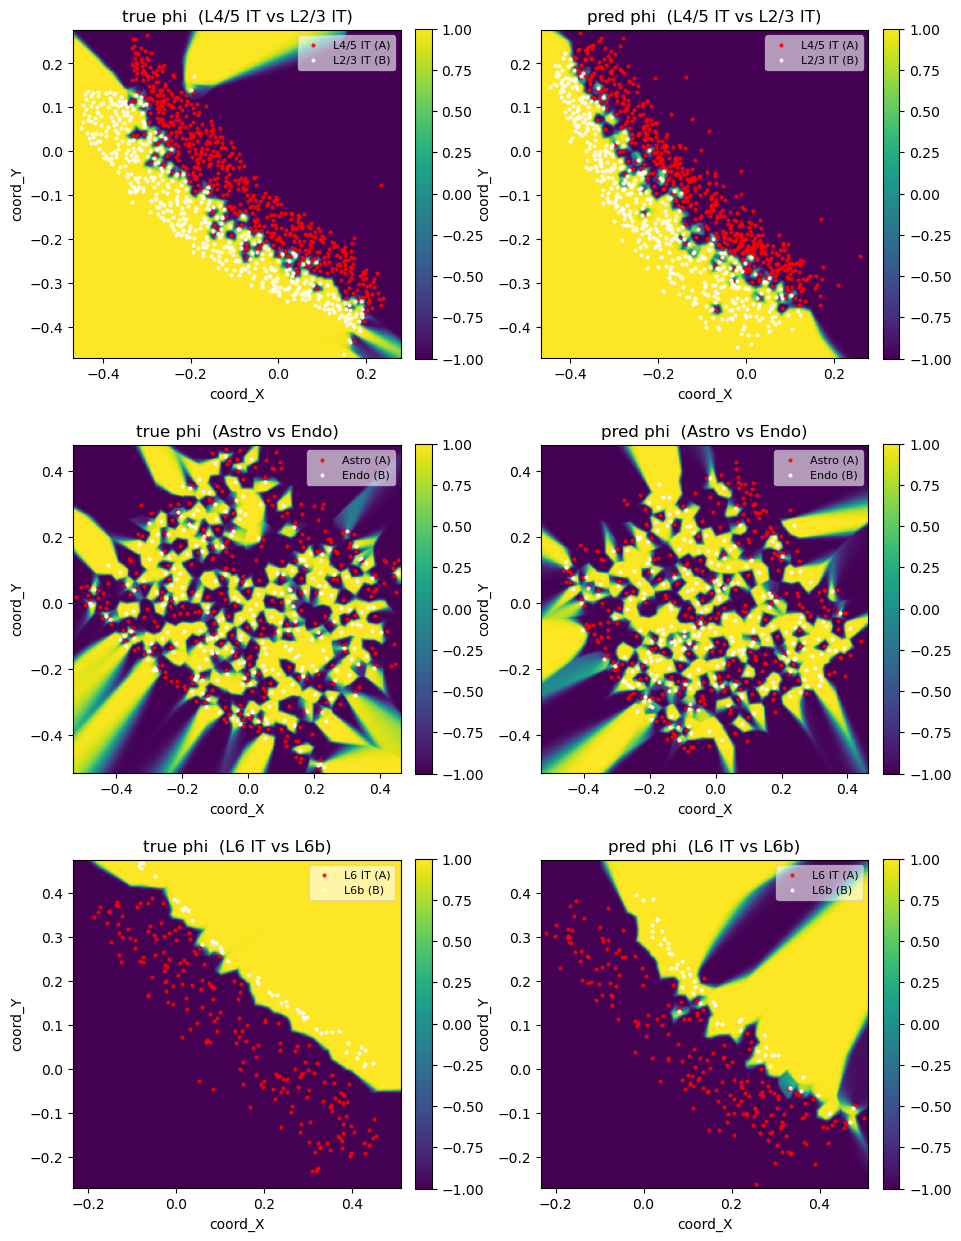

In [ ]:
fig, axes = plt.subplots(
    len(selected_pairs), 2,
    figsize=(9.5, 4.2 * len(selected_pairs)),
    squeeze=False,
)

for row, pair in enumerate(selected_pairs):
    ct_a, ct_b = pair
    res = pair_visual_results[pair]
    grid_x = res["grid_x"]
    grid_y = res["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(),
              grid_y.min().item(), grid_y.max().item()]

    # Cell positions for this pair, used as a scatter overlay (true side
    # against true phi, pred side against pred phi).
    mask_a = type_mask_for(ct_a)
    mask_b = type_mask_for(ct_b)
    true_a = to_numpy(true_pos[mask_a])
    true_b = to_numpy(true_pos[mask_b])
    pred_a = to_numpy(pred_pos[mask_a])
    pred_b = to_numpy(pred_pos[mask_b])

    panels = [
        (res["phi_true"],  f"true phi  ({ct_a} vs {ct_b})",  true_a, true_b),
        (res["phi_pred"],  f"pred phi  ({ct_a} vs {ct_b})",  pred_a, pred_b),
    ]
    for col, (image, title, pts_a, pts_b) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(
            to_numpy(image), origin="lower", extent=extent,
            cmap="viridis", vmin=-1.0, vmax=1.0,
        )
        # Cell A in red, cell B in white -- matches the -1/+1 polarity of phi.
        ax.scatter(pts_a[:, 0], pts_a[:, 1], s=4, c="red",   label=f"{ct_a} (A)", alpha=0.8)
        ax.scatter(pts_b[:, 0], pts_b[:, 1], s=4, c="white", label=f"{ct_b} (B)", alpha=0.8)
        ax.set_title(title)
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.legend(loc="upper right", fontsize=8, framealpha=0.6)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## Plot Cahn-Hilliard energy densities for each pair

Energy is concentrated along the Voronoi frontier between A and B cells (where $\phi_{AB}$ transitions from $-1$ to $+1$): both the well term $(\phi^2-1)^2$ and the gradient penalty $|\nabla\phi|^2$ peak there. The integrated energy is what `VoronoiPhasePairEnergyLoss` compares between true and predicted positions.

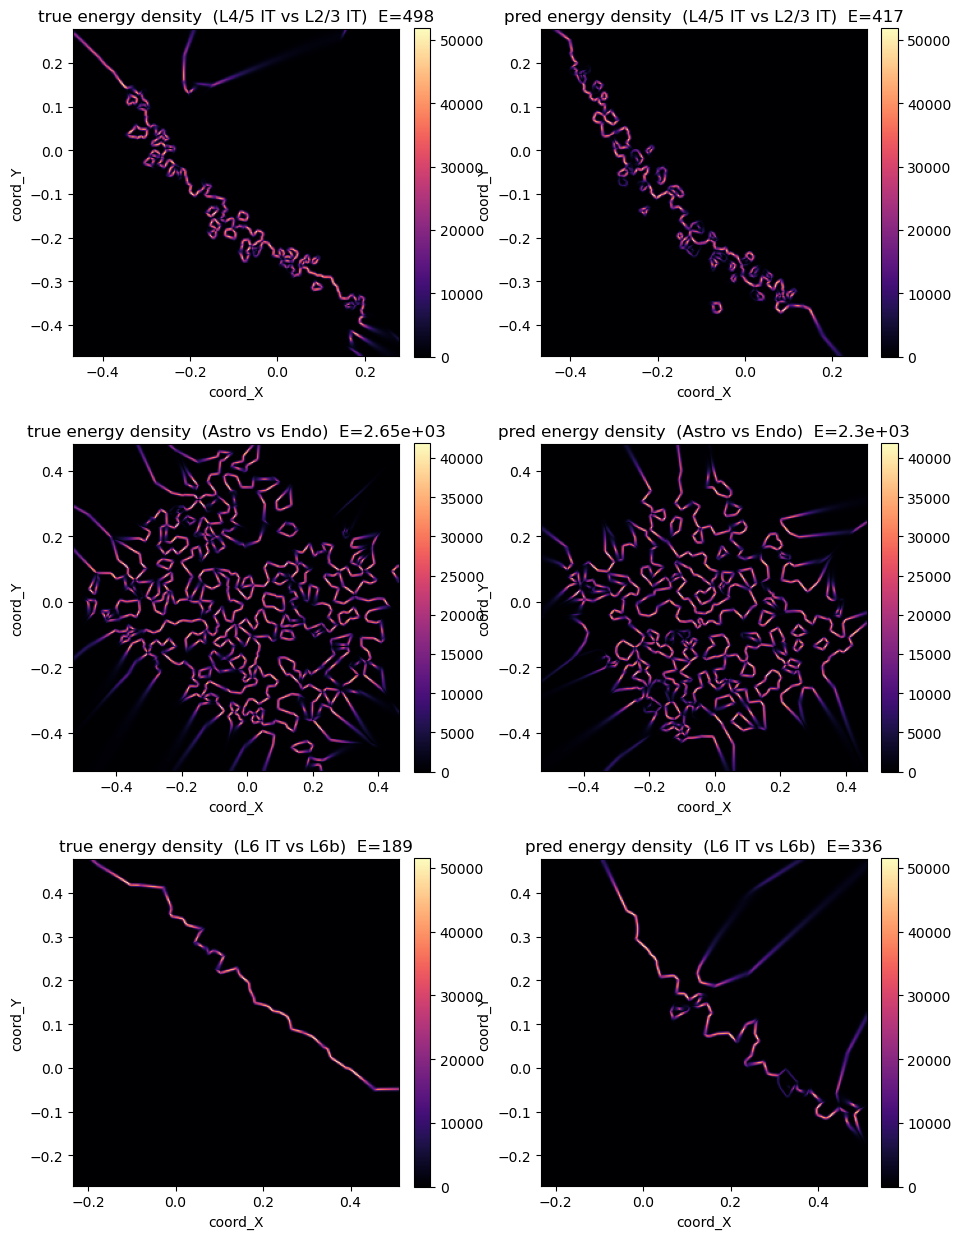

In [ ]:
fig, axes = plt.subplots(
    len(selected_pairs), 2,
    figsize=(9.5, 4.2 * len(selected_pairs)),
    squeeze=False,
)

for row, pair in enumerate(selected_pairs):
    ct_a, ct_b = pair
    res = pair_visual_results[pair]
    grid_x = res["grid_x"]
    grid_y = res["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(),
              grid_y.min().item(), grid_y.max().item()]

    e_density_true = res["energy_density_true"]
    e_density_pred = res["energy_density_pred"]
    # Use a common vmax across the two panels of a row so true/pred are
    # directly comparable visually.
    vmax = float(max(e_density_true.max().item(), e_density_pred.max().item()))

    panels = [
        (e_density_true, f"true energy density  ({ct_a} vs {ct_b})  E={res['e_true'].item():.3g}"),
        (e_density_pred, f"pred energy density  ({ct_a} vs {ct_b})  E={res['e_pred'].item():.3g}"),
    ]
    for col, (image, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(
            to_numpy(image), origin="lower", extent=extent,
            cmap="magma", vmin=0.0, vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## Compute the loss for every cell-type pair

For each unordered pair `(A, B)` with at least `VORONOI_MIN_CELLS_PER_PAIR` cells of each type:

`rel_diff = |E_pred - E_gt| / (|E_gt| + EPS)`

`loss = 1 - exp(-rel_diff)`

In [ ]:
# Iterate over every unordered pair of cell types that has enough cells.
# Each call to compute_pair_results does its own cdist; for many pairs the
# VoronoiPhasePairEnergyLoss class is more efficient because it computes
# per-type distance fields *once* and reuses them across all pairs. This
# loop is just a notebook-level diagnostic.
all_pair_rows = []

valid_types = [
    ct for ct in cell_labels.value_counts().index.tolist()
    if int((cell_labels.values == ct).sum()) >= VORONOI_MIN_CELLS_PER_PAIR
]

with torch.no_grad():
    for i in range(len(valid_types)):
        for j in range(i + 1, len(valid_types)):
            ct_a, ct_b = valid_types[i], valid_types[j]
            res = compute_pair_results(ct_a, ct_b)
            if res is None:
                continue
            all_pair_rows.append(
                {
                    "cell_type_a": ct_a,
                    "cell_type_b": ct_b,
                    "n_a": res["n_a"],
                    "n_b": res["n_b"],
                    "E_true": res["e_true"].item(),
                    "E_pred": res["e_pred"].item(),
                    "rel_diff": res["rel_diff"].item(),
                    "loss": res["loss"].item(),
                }
            )

pair_loss_df = (
    pd.DataFrame(all_pair_rows)
    .sort_values("loss", ascending=False)
    .reset_index(drop=True)
)
print(f"Number of valid pairs: {len(pair_loss_df)}")
print(
    f"Mean loss across pairs: {pair_loss_df['loss'].mean():.6g}   "
    f"(this is the sample loss VoronoiPhasePairEnergyLoss returns)"
)
display(pair_loss_df)

Number of valid pairs: 210
Mean loss across pairs: 0.123654   (this is the sample loss VoronoiPhasePairEnergyLoss returns)


,cell_type_a,cell_type_b,n_a,n_b,E_true,E_pred,rel_diff,loss
0,L6 CT,L6b,447,54,205.151917,368.042053,0.793998,0.547966
1,L6 IT,L6b,193,54,188.671677,335.856140,0.780109,0.541644
2,L4/5 IT,L5 IT,558,310,287.947449,475.305573,0.650668,0.478303
3,L4/5 IT,L5 ET,558,163,278.341248,456.054810,0.638474,0.471902
4,PVM,SMC,79,48,713.829041,1159.076782,0.623746,0.464067
...,...,...,...,...,...,...,...,...
205,L2/3 IT,Endo,476,253,693.314758,691.236145,0.002998,0.002994
206,VLMC,Sst,71,35,343.959351,343.193756,0.002226,0.002223
207,Vip,Lamp5,43,29,873.502563,874.915344,0.001617,0.001616
208,SMC,Vip,48,43,913.172119,912.123901,0.001148,0.001147


## Plot per-pair Voronoi phase-pair loss

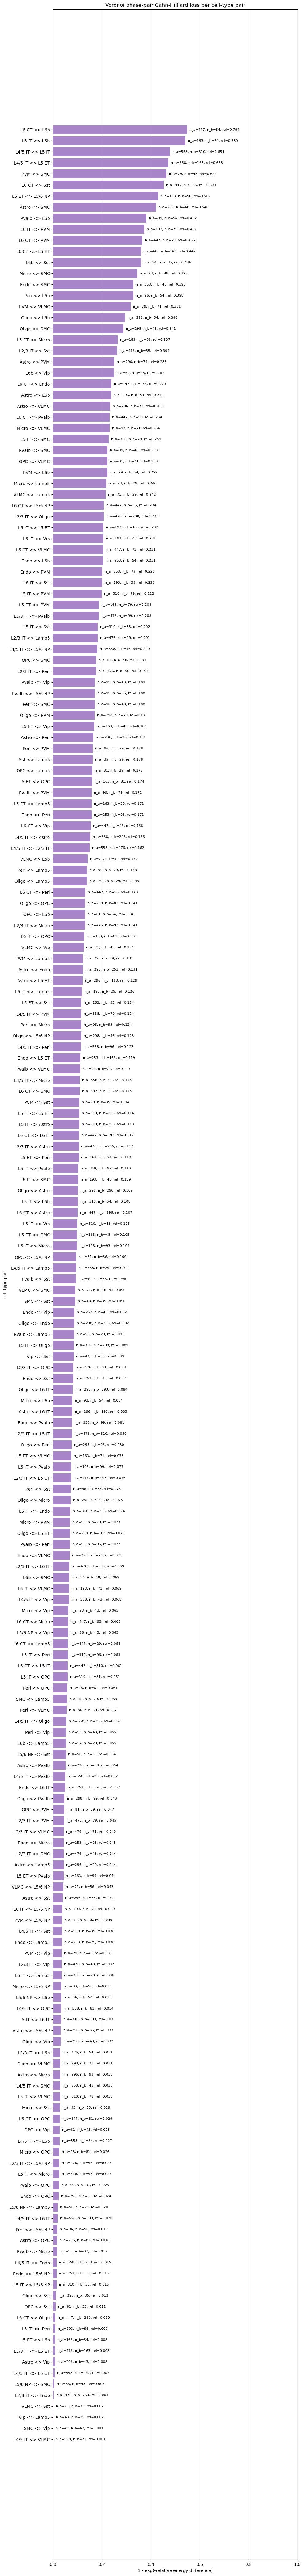

In [ ]:
plot_df = pair_loss_df.sort_values("loss", ascending=True)
labels = plot_df.apply(lambda r: f"{r['cell_type_a']} <> {r['cell_type_b']}", axis=1)

fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(plot_df))))
ax.barh(labels, plot_df["loss"], color="tab:purple", alpha=0.8)
ax.set_xlabel("1 - exp(-relative energy difference)")
ax.set_ylabel("cell type pair")
ax.set_title("Voronoi phase-pair Cahn-Hilliard loss per cell-type pair")
ax.set_xlim(0, max(1.0, float(plot_df["loss"].max()) * 1.05))
ax.grid(axis="x", alpha=0.25)

# Annotate each bar with cell counts and the relative difference, similar
# to the per-cell-type bar chart above.
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["loss"] + 0.01, i,
        f"n_a={int(row['n_a'])}, n_b={int(row['n_b'])}, rel={row['rel_diff']:.3f}",
        va="center", fontsize=8,
    )

plt.tight_layout()

## Run `VoronoiPhasePairEnergyLoss` on the whole slice

The hand-rolled per-pair loop above is a sanity check; the actual training-time loss is `VoronoiPhasePairEnergyLoss` from `loss_function_plus.py`. It builds **one shared grid per sample** and computes per-cell-type distance fields **once**, then iterates over all pairs reusing those fields -- much cheaper than the loop above when there are many cell types.

We also plug it into `CombinedLossFunction` via the new `voronoi_weight` and `voronoi_*` parameters.

In [ ]:
# Reuse the dataholders built earlier for CombinedLossFunction (they already
# carry positions, node_mask and cell_class as a [B=1, N] tensor of integer ids).
voronoi_loss_fn = VoronoiPhasePairEnergyLoss(
    transition_width=VORONOI_TRANSITION_WIDTH,
    grid_resolution=VORONOI_GRID_RESOLUTION,
    kappa=VORONOI_KAPPA,
    soft_beta=VORONOI_SOFT_BETA,
    square_bbox=VORONOI_SQUARE_BBOX,
    margin=VORONOI_MARGIN,
    eps=VORONOI_EPS,
    min_cells_per_type=VORONOI_MIN_CELLS_PER_PAIR,
).to(DEVICE)

with torch.no_grad():
    voronoi_loss_value, _ = voronoi_loss_fn(
        combined_pred_holder,
        combined_true_holder,
        train_stage=False,
        log=False,
    )

print(f"VoronoiPhasePairEnergyLoss on whole slice: {voronoi_loss_value.item():.6g}")
print(
    f"   (manual mean over all valid pairs above:    {pair_loss_df['loss'].mean():.6g})"
)

# Combined loss with the new Voronoi component enabled. We turn off the
# CH-AUC component (ch_weight=0) so the comparison with MSE + Voronoi is clean.
combined_loss_fn_voronoi = CombinedLossFunction(
    mse_weight=1.0,
    ch_weight=0.0,
    voronoi_weight=1.0,
    voronoi_transition_width=VORONOI_TRANSITION_WIDTH,
    voronoi_grid_resolution=VORONOI_GRID_RESOLUTION,
    voronoi_kappa=VORONOI_KAPPA,
    voronoi_soft_beta=VORONOI_SOFT_BETA,
    voronoi_square_bbox=VORONOI_SQUARE_BBOX,
    voronoi_margin=VORONOI_MARGIN,
    voronoi_min_cells_per_type=VORONOI_MIN_CELLS_PER_PAIR,
    eps=VORONOI_EPS,
).to(DEVICE)

with torch.no_grad():
    mse_component, _ = combined_loss_fn_voronoi.mse_loss(
        combined_pred_holder, combined_true_holder, train_stage=False, log=False,
    )
    voronoi_component, _ = combined_loss_fn_voronoi.voronoi_loss(
        combined_pred_holder, combined_true_holder, train_stage=False, log=False,
    )
    total_loss, _ = combined_loss_fn_voronoi(
        combined_pred_holder, combined_true_holder, train_stage=False, log=False,
    )

print()
print("Combined loss (mse_weight=1, ch_weight=0, voronoi_weight=1):")
print(f"   MSE component:                     {mse_component.item():.6g}")
print(f"   Voronoi phase-pair component:      {voronoi_component.item():.6g}")
print(f"   Total combined loss:               {total_loss.item():.6g}")

VoronoiPhasePairEnergyLoss on whole slice: 0.126844
   (manual mean over all valid pairs above:    0.123654)

Combined loss (mse_weight=1, ch_weight=0, voronoi_weight=1):
   MSE component:                     0.0362132
   Voronoi phase-pair component:      0.126844
   Total combined loss:               0.163057
